# ESA CCI Toolbox with Python and R

This notebook uses one Python kernel and executes selected cells with R through `rpy2`. Python opens and reduces an ESA CCI Ocean Colour dataset. Only the resulting small time-series table is transferred to R, where it is visualized with `ggplot2`. A statistical summary is then returned to Python.

## 1. Load R support

The notebook does not switch kernels. The `rpy2.ipython` extension adds the `%%R` cell magic to the active Python kernel.

In [1]:
%load_ext rpy2.ipython

## 2. Open the dataset in Python

The ESA CCI Toolbbox returns the data object together with the store identifier.

In [2]:
from esa_climate_toolbox import core, ops

dataset_id = (
    "ESACCI-OC-L3S-OC_PRODUCTS-MERGED-8D_DAILY_4km_GEO_PML_OCx_QAA-2022-fv6.0.zarr"
)
data_store_id = "esa-cci-zarr"

ocean_colour_ds, opened_from_store = core.open_data(
    dataset_id=dataset_id,
    data_store_id=data_store_id,
)

print(f"Opened from store: {opened_from_store}")
ocean_colour_ds

Opened from store: ESACCI-OC-L3S-OC_PRODUCTS-MERGED-8D_DAILY_4km_GEO_PML_OCx_QAA-2022-fv6.0.zarr


<xarray.Dataset> Size: 16TB
Dimensions:             (time: 1166, lat: 4320, lon: 8640)
Coordinates:
  * time                (time) datetime64[ns] 9kB 1997-09-04 ... 2022-12-27
  * lat                 (lat) float64 35kB 89.98 89.94 89.9 ... -89.94 -89.98
  * lon                 (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables: (12/94)
    MERIS_nobs_sum      (time, lat, lon) float32 174GB dask.array<chunksize=(1, 2160, 2160), meta=np.ndarray>
    MODISA_nobs_sum     (time, lat, lon) float32 174GB dask.array<chunksize=(1, 2160, 2160), meta=np.ndarray>
    OLCI-A_nobs_sum     (time, lat, lon) float32 174GB dask.array<chunksize=(1, 2160, 2160), meta=np.ndarray>
    OLCI-B_nobs_sum     (time, lat, lon) float32 174GB dask.array<chunksize=(1, 2160, 2160), meta=np.ndarray>
    Rrs_412             (time, lat, lon) float32 174GB dask.array<chunksize=(1, 2160, 2160), meta=np.ndarray>
    Rrs_412_bias        (time, lat, lon) float32 174GB dask.array<chunksize=(1, 2160, 2160), meta=np.ndarray>
    ...                  ...
    water_class4        (time, lat, lon) float32 174GB dask.array<chunksize=(1, 2160, 2160), meta=np.ndarray>
    water_class5        (time, lat, lon) float32 174GB dask.array<chunksize=(1, 2160, 2160), meta=np.ndarray>
    water_class6        (time, lat, lon) float32 174GB dask.array<chunksize=(1, 2160, 2160), meta=np.ndarray>
    water_class7        (time, lat, lon) float32 174GB dask.array<chunksize=(1, 2160, 2160), meta=np.ndarray>
    water_class8        (time, lat, lon) float32 174GB dask.array<chunksize=(1, 2160, 2160), meta=np.ndarray>
    water_class9        (time, lat, lon) float32 174GB dask.array<chunksize=(1, 2160, 2160), meta=np.ndarray>
Attributes: (12/51)
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    NCO:                               netCDF Operators version 4.7.5 (Homepa...
    cdm_data_type:                     Grid
    comment:                           See summary attribute
    creation_date:                     Tue Jan 31 11:54:16 2023
    ...                                ...
    time_coverage_end:                 20221227T000000Z
    time_coverage_resolution:          P8D
    time_coverage_start:               19970904T000000Z
    title:                             ESA CCI Ocean Colour Product
    tracking_id:                       518fbec7-8d82-4961-a1e4-19736132d4b7
    catalogue_url:                     https://catalogue.ceda.ac.uk/uuid/0875...

We use operations "select_var" and and "subset_temporal" to create a temporal and variable subset. Then, we use the "tseries_point" operation to create a time series for a location in the Irawaddy Delta region.

In [3]:
atot_variables = [
    "atot_412",
    "atot_443",
    "atot_490",
    "atot_510",
    "atot_560",
    "atot_665",
]
time_range=["2015-01-01", "2015-12-31"]
irawaddy_delta_loc = (96.44,16.23)

In [4]:
import folium
import shapely

irawaddy_point = shapely.Point(irawaddy_delta_loc)
m = folium.Map(location=[irawaddy_point.y, irawaddy_point.x], zoom_start=7)
folium.GeoJson(irawaddy_point.__geo_interface__).add_to(m)
m

In [5]:
atot_ds = ops.select_var(ds=ocean_colour_ds, var=atot_variables)
atot_ds = ops.subset_temporal(
    ds=atot_ds,
    time_range=time_range,
)

atot_ts = ops.tseries_point(ds=atot_ds, point=irawaddy_delta_loc)

atot_ts

<xarray.Dataset> Size: 1kB
Dimensions:   (time: 46)
Coordinates:
  * time      (time) datetime64[ns] 368B 2015-01-01 2015-01-09 ... 2015-12-27
    lat       float64 8B 16.23
    lon       float64 8B 96.44
Data variables:
    atot_412  (time) float32 184B dask.array<chunksize=(1,), meta=np.ndarray>
    atot_443  (time) float32 184B dask.array<chunksize=(1,), meta=np.ndarray>
    atot_490  (time) float32 184B dask.array<chunksize=(1,), meta=np.ndarray>
    atot_510  (time) float32 184B dask.array<chunksize=(1,), meta=np.ndarray>
    atot_560  (time) float32 184B dask.array<chunksize=(1,), meta=np.ndarray>
    atot_665  (time) float32 184B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    NCO:                               netCDF Operators version 4.7.5 (Homepa...
    cdm_data_type:                     Grid
    comment:                           See summary attribute
    creation_date:                     Tue Jan 31 11:54:16 2023
    ...                                ...
    time_coverage_end:                 2015-12-27T00:00:00
    time_coverage_resolution:          P8D
    time_coverage_start:               2015-01-01T00:00:00
    title:                             ESA CCI Ocean Colour Product
    tracking_id:                       518fbec7-8d82-4961-a1e4-19736132d4b7
    catalogue_url:                     https://catalogue.ceda.ac.uk/uuid/0875...

The point selection contains only 46 time steps and six variables. Calling `to_dataframe()` now computes and transfers this reduced result; the complete raster dataset is never converted.

In [6]:
absorption_table = (
    atot_ts.to_dataframe()
    .reset_index()
    [["time", *atot_variables]]
)

absorption_table.head()

,time,atot_412,atot_443,atot_490,atot_510,atot_560,atot_665
0,2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-09,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-17,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-25,1.374144,0.690706,0.490114,0.398998,0.264867,0.562984
4,2015-02-02,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Visualize the time series in R

The `-i absorption_table` option makes the small Pandas DataFrame available as an R data frame. The plot is displayed in the notebook and also written to `output/absorption_time_series_notebook.png`. The `-o absorption_summary` option returns the R summary to Python.

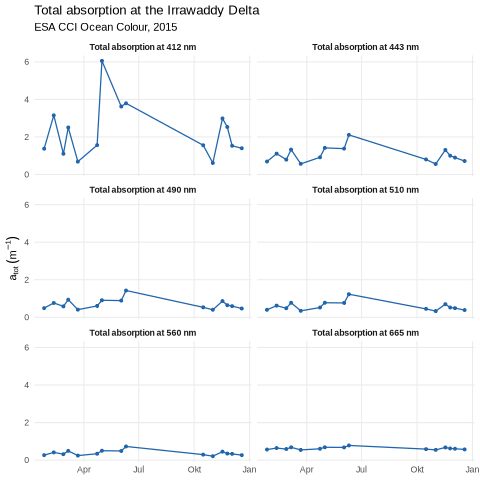

In [7]:
%%R -i absorption_table -o absorption_summary
library(ggplot2)

atot_variables <- c(
  "atot_412", "atot_443", "atot_490",
  "atot_510", "atot_560", "atot_665"
)

absorption_long <- data.frame(
  time = rep(absorption_table$time, times = length(atot_variables)),
  wavelength = rep(
    sub("^atot_", "", atot_variables),
    each = nrow(absorption_table)
  ),
  absorption = unlist(absorption_table[atot_variables], use.names = FALSE)
)

absorption_long$wavelength <- factor(
  absorption_long$wavelength,
  levels = sub("^atot_", "", atot_variables)
)
absorption_long <- absorption_long[!is.na(absorption_long$absorption), ]

wavelength_labels <- setNames(
  paste0(
    "Total absorption at ",
    sub("^atot_", "", atot_variables),
    " nm"
  ),
  sub("^atot_", "", atot_variables)
)

absorption_plot <- ggplot(
  absorption_long,
  aes(x = time, y = absorption, group = 1)
) +
  geom_line(linewidth = 0.6, colour = "#2166ac") +
  geom_point(size = 1.2, colour = "#2166ac") +
  facet_wrap(
    vars(wavelength),
    ncol = 2,
    scales = "fixed",
    labeller = as_labeller(wavelength_labels)
  ) +
  labs(
    title = "Total absorption at the Irrawaddy Delta",
    subtitle = "ESA CCI Ocean Colour, 2015",
    x = NULL,
    y = expression(a[tot] ~ (m^{-1}))
  ) +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    strip.text = element_text(face = "bold")
  )

dir.create("output", showWarnings = FALSE, recursive = TRUE)
ggsave(
  filename = "output/absorption_time_series_notebook.png",
  plot = absorption_plot,
  width = 10,
  height = 8,
  units = "in",
  dpi = 150
)

absorption_summary <- aggregate(
  absorption ~ wavelength,
  data = absorption_long,
  FUN = mean
)
names(absorption_summary)[2] <- "mean_absorption"

absorption_plot

## 4. Use the R result in Python

After the R cell has finished, `absorption_summary` is a Pandas DataFrame in the Python namespace. This demonstrates data transfer in the opposite direction without moving the original raster data.

In [8]:
absorption_summary

,wavelength,mean_absorption
1,412,2.297207
2,443,1.039250
3,490,0.701383
4,510,0.585662
5,560,0.378507
6,665,0.624349
